# Loss Landscape Visualization

Sweeps all pairs of trainable AdEx parameters over a grid, simulates at each point,
and plots the loss surfaces as:
1. A lower-triangle grid of 2D contour plots (21 pairs)
2. Individual 3D surface plots with contour projection (Ackley-style)

In [1]:
import copy
import logging
import time
from itertools import combinations

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core import simulate_jaxley
from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatures,
    GuarinoLossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    guarino_loss,
    make_guarino_loss_fn,
    make_van_rossum_loss_fn,
    spike_train_from_voltage,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

import matplotlib.pyplot as plt
from matplotlib import cm


## 1. Load & Crop Data

In [2]:
initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0
print(initial_params)

current_pA = initial_params["I"]

t_max_ms = 100
dt_ms = 0.025
T = np.linspace(0, t_max_ms, int(t_max_ms / dt_ms))

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=current_pA,
    stim_duration_ms=100,
    dt_ms=dt_ms,
    t_max_ms=t_max_ms,
    stim_delay_ms=0.0,
    use_surrogate=False,
)

T = np.append(T, T[-1] + dt_ms)
print(len(T))

INFO:2026-04-23 10:44:26,301:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


{'C_m': 200.0, 'g_L': 12.0, 'E_L': -70.0, 'v_T': -50.0, 'delta_T': 2.0, 'v_reset': -58.0, 'v_threshold': 0.0, 'tau_w': 300.0, 'a': 2.0, 'b': 60.0, 'I': 500.0}


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
4001


## 2. Setup Cell & Loss Function

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Initial loss: 0.0000
Trainable parameters (8): ['capacitance', 'g_L', 'E_L', 'v_T', 'v_reset', 'tau_w', 'a', 'b']
Initial parameters: {'C_m': 200.0, 'g

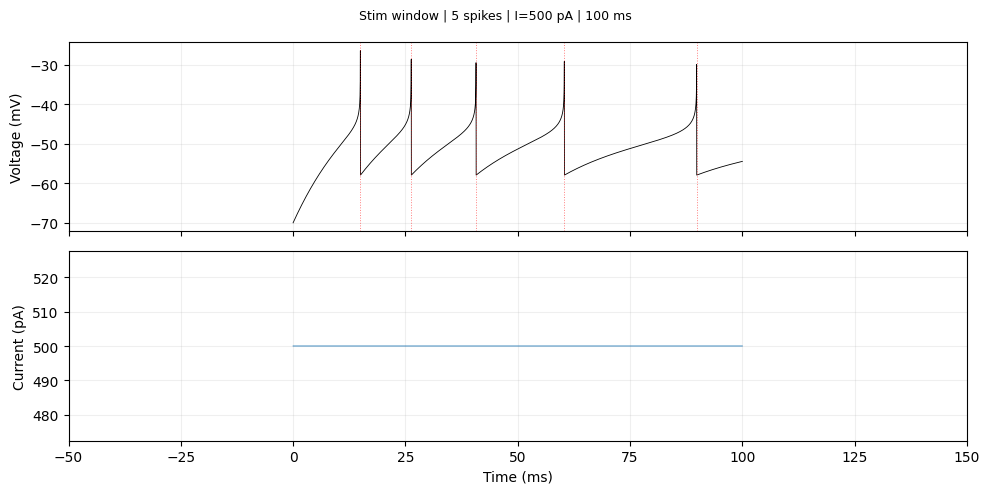

In [3]:
training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.01,
    n_epochs=1,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
)

trace_stim_window_plot(TraceData(
    T,
    sim_init.voltage,
    np.full(len(T), initial_params["I"]),
    dt_ms,
    sim_init.spike_times,
    0,
    len(T),
    initial_params["I"]))

cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=np.full(len(T), initial_params["I"]),
    dt_ms=dt_ms,
    config=training_config,
)

target_voltage = jnp.array(sim_init.voltage)
stim_end_index = t_max_ms  # already 0-based in cropped trace

# Detect spikes from target trace (binary spike train for Van Rossum distance)
exp_spike_train = jnp.array(sim_init.spikes)

loss_name = "VanRossum"
loss_fn = make_van_rossum_loss_fn(
    cell=cell,
    data_stimuli=data_stimuli,
    t_max=t_max,
    dt_ms=dt_ms,
    exp_spike_train=exp_spike_train,
    stim_end_index=len(sim_init.voltage),
    loss_config=VanRossumLossConfig(),
)


# Build param name -> index mapping
param_index = {}
for i, p in enumerate(trainable_params):
    for k in p:
        param_index[k.replace("AdEx_", "")] = i

PARAM_NAMES = list(param_index.keys())
N_PARAMS = len(PARAM_NAMES)

loss_init = loss_fn(trainable_params)
print(f"Initial loss: {float(loss_init):.4f}")
print(f"Trainable parameters ({N_PARAMS}): {PARAM_NAMES}")
print(f"Initial parameters: {initial_params}")


## 3. Sweep All Parameter Pairs

For each of the C(7,2) = 21 pairs, build a grid over their PARAM_BOUNDS and
evaluate the loss. Non-swept parameters stay at their default values.

In [4]:
GRID_SIZE = 10  # 20x20 per pair; 21 pairs * 400 = 8400 simulations

pairs = list(combinations(range(N_PARAMS), 2))
print(f"{len(pairs)} parameter pairs, {GRID_SIZE}x{GRID_SIZE} grid each")
print(f"Total simulations: {len(pairs) * GRID_SIZE**2}")

28 parameter pairs, 10x10 grid each
Total simulations: 2800


In [5]:
# Storage for all grids
grids = {}  # (i, j) -> {"X": ..., "Y": ..., "Z": ...}

t_start = time.time()

for pair_idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    bx, by = PARAM_BOUNDS[px], PARAM_BOUNDS[py]

    x_vals = np.linspace(bx.min, bx.max, GRID_SIZE)
    y_vals = np.linspace(by.min, by.max, GRID_SIZE)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.full((GRID_SIZE, GRID_SIZE), np.nan)

    ix, iy = param_index[px], param_index[py]

    pxrc = f"AdEx_{px}" if px != "capacitance" else px
    pyrc = f"AdEx_{py}" if py != "capacitance" else py
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            params_rc = copy.deepcopy(trainable_params)
            params_rc[ix] = {pxrc: jnp.array([X[r, c]])}
            params_rc[iy] = {pyrc: jnp.array([Y[r, c]])}
            try:
                Z[r, c] = float(loss_fn(params_rc))
            except Exception:
                Z[r, c] = np.nan

    grids[(pi, pj)] = {"X": X, "Y": Y, "Z": Z}

    elapsed = time.time() - t_start
    eta = elapsed / (pair_idx + 1) * (len(pairs) - pair_idx - 1)
    print(
        f"  [{pair_idx+1:2d}/{len(pairs)}] {px:>8s} vs {py:<8s}  "
        f"loss=[{np.nanmin(Z):.1f}, {np.nanmax(Z):.1f}]  "
        f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s"
    )

print(f"\nTotal time: {time.time() - t_start:.0f}s")

  [ 1/28] capacitance vs g_L       loss=[0.5, 19.8]  elapsed=12s  ETA=333s
  [ 2/28] capacitance vs E_L       loss=[1.0, 16.0]  elapsed=25s  ETA=326s
  [ 3/28] capacitance vs v_T       loss=[0.6, 30.4]  elapsed=38s  ETA=318s
  [ 4/28] capacitance vs v_reset   loss=[0.4, 79.1]  elapsed=51s  ETA=303s
  [ 5/28] capacitance vs tau_w     loss=[0.8, 36.1]  elapsed=63s  ETA=290s
  [ 6/28] capacitance vs a         loss=[0.6, 11.9]  elapsed=76s  ETA=280s
  [ 7/28] capacitance vs b         loss=[0.7, 3193.1]  elapsed=92s  ETA=275s
  [ 8/28]      g_L vs E_L       loss=[0.3, 3.3]  elapsed=105s  ETA=264s
  [ 9/28]      g_L vs v_T       loss=[0.3, 7.9]  elapsed=119s  ETA=251s
  [10/28]      g_L vs v_reset   loss=[0.4, 17.3]  elapsed=133s  ETA=239s
  [11/28]      g_L vs tau_w     loss=[0.2, 2.6]  elapsed=146s  ETA=226s
  [12/28]      g_L vs a         loss=[0.1, 1.9]  elapsed=160s  ETA=214s
  [13/28]      g_L vs b         loss=[0.2, 5.4]  elapsed=175s  ETA=202s
  [14/28]      E_L vs v_T       loss=[1.

## 4. Triangle Grid — All Pairs (2D Contour)

Lower-triangle matrix: row = second parameter, column = first parameter.
Each cell shows a filled contour of the loss landscape for that pair.

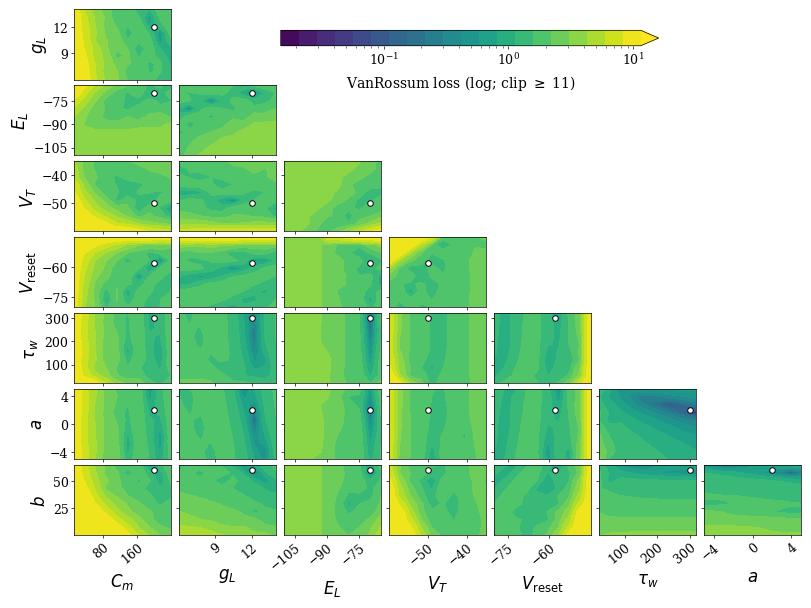

Saved to vanrossum_loss_landscape_grid.pdf
Loss range across all pairs: [0.015, 9.65e+04]
Colorbar clip at 95th percentile: 11.5


In [6]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, MaxNLocator

PARAM_LABELS = {
    "capacitance": r"$C_m$",
    "g_L": r"$g_L$",
    "E_L": r"$E_L$",
    "v_T": r"$V_T$",
    "delta_T": r"$\Delta_T$",
    "v_reset": r"$V_\mathrm{reset}$",
    "tau_w": r"$\tau_w$",
    "a": r"$a$",
    "b": r"$b$",
}

# Units per loss function (missing entries render without a unit bracket)
LOSS_UNITS = {
    "MSE": r"mV$^2$",
}

def _map_name_to_initial(s):
    return "C_m" if s == "capacitance" else s

all_Z = np.concatenate([g["Z"].ravel() for g in grids.values()])
positive = all_Z[np.isfinite(all_Z) & (all_Z > 0)]
vmin = float(np.min(positive)) if positive.size else 1e-6
vmax_clip = float(np.nanpercentile(all_Z, 95))
vmax_clip = max(vmax_clip, vmin * 10)
vmax_true = float(np.nanmax(all_Z))
norm = LogNorm(vmin=vmin, vmax=vmax_clip)
levels = np.geomspace(vmin, vmax_clip, 21)

# Rendered at thesis print size: ~9x7 inches fits full-page landscape on A4
# (use \begin{sidewaysfigure}\includegraphics{...}\end{sidewaysfigure} in LaTeX).
# Fonts stay legible because LaTeX no longer rescales the figure.
with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
}):
    fig, axes = plt.subplots(
        N_PARAMS, N_PARAMS, figsize=(9.0, 7.0), squeeze=False,
    )

    # Diagonal cells stay hidden — redundant with outer row/column labels.
    for ax_row in axes:
        for ax in ax_row:
            ax.set_visible(False)

    mappable = None
    for (pi, pj), g in grids.items():
        ax = axes[pj, pi]
        ax.set_visible(True)

        Z_plot = np.clip(g["Z"], vmin, vmax_clip)
        cs = ax.contourf(
            g["X"], g["Y"], Z_plot,
            levels=levels, cmap="viridis", norm=norm, extend="max",
        )
        if mappable is None:
            mappable = cs

        ax.plot(
            initial_params[_map_name_to_initial(PARAM_NAMES[pi])],
            initial_params[_map_name_to_initial(PARAM_NAMES[pj])],
            marker="o", markersize=4,
            markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.7,
            linestyle="none",
        )

        if pj == N_PARAMS - 1:
            ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pi]], fontsize=12, labelpad=4)
            for lbl in ax.get_xticklabels():
                lbl.set_rotation(40)
                lbl.set_ha("right")
                lbl.set_rotation_mode("anchor")
        else:
            ax.set_xticklabels([])
        if pi == 0:
            ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[pj]], fontsize=12, labelpad=3)
        else:
            ax.set_yticklabels([])

        ax.xaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.tick_params(direction="out", length=2.2, width=0.5, pad=1.5)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    fig.subplots_adjust(
        left=0.06, right=0.985, bottom=0.11, top=0.97,
        wspace=0.08, hspace=0.08,
    )

    pos_row = axes[1, 0].get_position()
    cbar_width = 0.42
    cbar_ax = fig.add_axes([
        0.5 - cbar_width / 2,
        pos_row.y0 + pos_row.height * 0.48,
        cbar_width,
        pos_row.height * 0.22,
    ])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")

    lo = int(np.floor(np.log10(vmin)))
    hi = int(np.ceil(np.log10(vmax_clip)))
    cbar.ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=min(hi - lo + 1, 8)))
    cbar.ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    )
    cbar.ax.xaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(
        which="major", labelsize=9, direction="out", length=2.5, width=0.5, pad=1.5
    )
    cbar.ax.tick_params(which="minor", direction="out", length=1.6, width=0.4)
    cbar.outline.set_linewidth(0.5)

    unit_str = LOSS_UNITS.get(loss_name)
    unit_bracket = f"  [{unit_str}]" if unit_str else ""
    cbar.set_label(
        rf"{loss_name} loss{unit_bracket} (log; clip $\geq$ {vmax_clip:.2g})",
        fontsize=10, labelpad=4,
    )

    plt.savefig(
        f"{loss_name.lower()}_loss_landscape_grid.pdf", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved to {loss_name.lower()}_loss_landscape_grid.pdf")
    print(f"Loss range across all pairs: [{float(np.nanmin(all_Z)):.3g}, {vmax_true:.3g}]")
    print(f"Colorbar clip at 95th percentile: {vmax_clip:.3g}")


## 5. Gradient Landscape

Same grid as section 3, but at each point evaluates `jax.grad(loss_fn)` and
records the partial derivatives w.r.t. the two swept parameters. The triangle
grid below shows the gradient magnitude (log scale) with normalized quiver
arrows for direction.

In [ ]:
grad_fn = jax.grad(loss_fn)

grad_grids = {}
t_start = time.time()
for pair_idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    pxrc = f"AdEx_{px}" if px != "capacitance" else px
    pyrc = f"AdEx_{py}" if py != "capacitance" else py
    g = grids[(pi, pj)]
    X, Y = g["X"], g["Y"]
    ix, iy = param_index[px], param_index[py]
    GX = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    GY = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            params_rc = copy.deepcopy(trainable_params)
            params_rc[ix] = {pxrc: jnp.array([X[r, c]])}
            params_rc[iy] = {pyrc: jnp.array([Y[r, c]])}
            try:
                gd = grad_fn(params_rc)
                GX[r, c] = float(gd[ix][pxrc][0])
                GY[r, c] = float(gd[iy][pyrc][0])
            except Exception:
                pass
    MAG = np.sqrt(GX ** 2 + GY ** 2)
    grad_grids[(pi, pj)] = {"X": X, "Y": Y, "GX": GX, "GY": GY, "MAG": MAG}
    elapsed = time.time() - t_start
    eta = elapsed / (pair_idx + 1) * (len(pairs) - pair_idx - 1)
    print(
        f"  [{pair_idx+1:2d}/{len(pairs)}] {px:>8s} vs {py:<8s}  "
        f"|grad|=[{np.nanmin(MAG):.2g}, {np.nanmax(MAG):.2g}]  "
        f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s"
    )
print(f"\nTotal time: {time.time() - t_start:.0f}s")

In [ ]:
all_M = np.concatenate([g["MAG"].ravel() for g in grad_grids.values()])
positive_M = all_M[np.isfinite(all_M) & (all_M > 0)]
gmin = float(np.min(positive_M)) if positive_M.size else 1e-12
gmax_clip = float(np.nanpercentile(all_M, 95))
gmax_clip = max(gmax_clip, gmin * 10)
gmax_true = float(np.nanmax(all_M))
gnorm = LogNorm(vmin=gmin, vmax=gmax_clip)
glevels = np.geomspace(gmin, gmax_clip, 21)

with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
}):
    fig, axes = plt.subplots(N_PARAMS, N_PARAMS, figsize=(9.0, 7.0), squeeze=False)
    for ax_row in axes:
        for ax in ax_row:
            ax.set_visible(False)

    mappable = None
    for (pi, pj), g in grad_grids.items():
        ax = axes[pj, pi]
        ax.set_visible(True)

        M = np.clip(g["MAG"], gmin, gmax_clip)
        cs = ax.contourf(
            g["X"], g["Y"], M,
            levels=glevels, cmap="magma", norm=gnorm, extend="max",
        )
        if mappable is None:
            mappable = cs

        # Normalized quiver: subsample to keep arrows readable.
        step = max(1, GRID_SIZE // 6)
        Xs = g["X"][::step, ::step]
        Ys = g["Y"][::step, ::step]
        GXs = g["GX"][::step, ::step]
        GYs = g["GY"][::step, ::step]
        Ms = np.sqrt(GXs ** 2 + GYs ** 2)
        denom = np.where(Ms > 0, Ms, 1.0)
        U = GXs / denom
        V = GYs / denom
        ax.quiver(
            Xs, Ys, U, V,
            color="white", alpha=0.85, pivot="middle",
            scale=22, width=0.012, headwidth=3.5, headlength=4,
        )

        ax.plot(
            initial_params[_map_name_to_initial(PARAM_NAMES[pi])],
            initial_params[_map_name_to_initial(PARAM_NAMES[pj])],
            marker="o", markersize=4,
            markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.7,
            linestyle="none",
        )

        if pj == N_PARAMS - 1:
            ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pi]], fontsize=12, labelpad=4)
            for lbl in ax.get_xticklabels():
                lbl.set_rotation(40)
                lbl.set_ha("right")
                lbl.set_rotation_mode("anchor")
        else:
            ax.set_xticklabels([])
        if pi == 0:
            ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[pj]], fontsize=12, labelpad=3)
        else:
            ax.set_yticklabels([])

        ax.xaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.tick_params(direction="out", length=2.2, width=0.5, pad=1.5)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    fig.subplots_adjust(
        left=0.06, right=0.985, bottom=0.11, top=0.97,
        wspace=0.08, hspace=0.08,
    )

    pos_row = axes[1, 0].get_position()
    cbar_width = 0.42
    cbar_ax = fig.add_axes([
        0.5 - cbar_width / 2,
        pos_row.y0 + pos_row.height * 0.48,
        cbar_width,
        pos_row.height * 0.22,
    ])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")

    lo = int(np.floor(np.log10(gmin)))
    hi = int(np.ceil(np.log10(gmax_clip)))
    cbar.ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=min(hi - lo + 1, 8)))
    cbar.ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    )
    cbar.ax.xaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(
        which="major", labelsize=9, direction="out", length=2.5, width=0.5, pad=1.5
    )
    cbar.ax.tick_params(which="minor", direction="out", length=1.6, width=0.4)
    cbar.outline.set_linewidth(0.5)
    cbar.set_label(
        rf"$\|\nabla\,${loss_name}$\|_2$ (log; clip $\geq$ {gmax_clip:.2g})",
        fontsize=10, labelpad=4,
    )

    plt.savefig(
        f"{loss_name.lower()}_grad_landscape_grid.pdf", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved to {loss_name.lower()}_grad_landscape_grid.pdf")
    print(f"Gradient magnitude range: [{float(np.nanmin(all_M)):.3g}, {gmax_true:.3g}]")
    print(f"Colorbar clip at 95th percentile: {gmax_clip:.3g}")

## 5. Individual 3D Surface Plots

Ackley-style 3D surface with contour projection for each parameter pair.

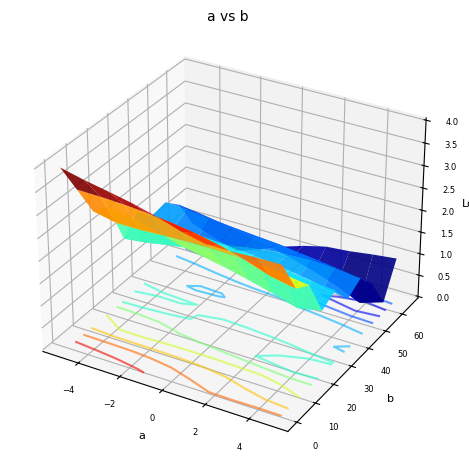

In [7]:
ax = plt.subplot(projection="3d")

surf = ax.plot_surface(
    X,
    Y,
    Z_plot,
    cmap=cm.jet,
    edgecolor="none",
    alpha=0.9,
    rstride=1,
    cstride=1,
)

# Contour projection on the floor
z_floor = ax.get_zlim()[0]
ax.contour(
    X,
    Y,
    Z_plot,
    levels=10,
    zdir="z",
    offset=z_floor,
    cmap=cm.jet,
    alpha=0.6,
)

ax.set_xlabel(px, fontsize=8, labelpad=2)
ax.set_ylabel(py, fontsize=8, labelpad=2)
ax.set_zlabel("Loss", fontsize=8, labelpad=2)
ax.set_title(f"{px} vs {py}", fontsize=10, pad=2)
ax.tick_params(labelsize=6)
ax.view_init(elev=30, azim=-60)

plt.tight_layout()
# plt.savefig(
#     f"{loss_name.lower()}_loss_landscape_3d_focus.pdf", dpi=150, bbox_inches="tight"
# )
plt.show()
# print(f"Saved to {loss_name.lower()}_loss_landscape_3d_focus.png")